In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import os
import sys
import datetime
from scipy import stats

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

In [2]:
df = pd.read_csv('../data/trading_data.csv')
print(df.head())

   Stock        Date and time  Last  Volume  Num. Trades      Bid      Ask  \
0  AZN.L  2026-01-05T05:00:00   NaN     NaN          NaN  13500.0  14522.0   
1  AZN.L  2026-01-05T07:50:00   NaN     NaN          NaN  16310.0  10874.0   
2  AZN.L  2026-01-05T07:51:00   NaN     NaN          NaN  16310.0  10874.0   
3  AZN.L  2026-01-05T07:52:00   NaN     NaN          NaN  16310.0  10874.0   
4  AZN.L  2026-01-05T07:53:00   NaN     NaN          NaN  16310.0  10874.0   

   Bid size  Ask size  
0     600.0      50.0  
1    6409.0   15376.0  
2    7065.0   16252.0  
3    7749.0   16609.0  
4    7141.0   16598.0  


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 679495 entries, 0 to 679494
Data columns (total 9 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Stock          679495 non-null  object 
 1   Date and time  679495 non-null  object 
 2   Last           538107 non-null  float64
 3   Volume         591033 non-null  float64
 4   Num. Trades    538107 non-null  float64
 5   Bid            676081 non-null  float64
 6   Ask            676040 non-null  float64
 7   Bid size       676082 non-null  float64
 8   Ask size       676041 non-null  float64
dtypes: float64(7), object(2)
memory usage: 46.7+ MB


In [4]:
# ── Section 1: Stock Selection ──────────────────────────────────────────────
all_stocks = df['Stock'].unique()
print(f"All stocks ({len(all_stocks)}): {all_stocks}")

# Fixed seed for reproducibility; pick 3 with a range of market caps
np.random.seed(42)
selected_stocks = np.random.choice(all_stocks, size=3, replace=False)
print(f"\nSelected stocks: {selected_stocks}")

df_sel = df[df['Stock'].isin(selected_stocks)].copy()
print(df_sel['Stock'].value_counts())

All stocks (20): ['AZN.L' 'BARC.L' 'BATS.L' 'BNZL.L' 'BRBY.L' 'EXPN.L' 'GLEN.L' 'GSK.L'
 'KGF.L' 'LLOY.L' 'MKS.L' 'NXT.L' 'PSN.L' 'RIO.L' 'RTO.L' 'SBRY.L' 'SVT.L'
 'ULVR.L' 'VOD.L' 'WTB.L']

Selected stocks: ['AZN.L' 'ULVR.L' 'SBRY.L']
Stock
AZN.L     34351
ULVR.L    34258
SBRY.L    33827
Name: count, dtype: int64


In [5]:
# ── Section 2: Data Engineering ─────────────────────────────────────────────
df_sel['datetime'] = pd.to_datetime(df_sel['Date and time'])
df_sel = df_sel.sort_values(['Stock', 'datetime']).reset_index(drop=True)

df_sel['date']        = df_sel['datetime'].dt.date
df_sel['hour']        = df_sel['datetime'].dt.hour
df_sel['time_only']   = df_sel['datetime'].dt.time
df_sel['minute_of_day'] = df_sel['datetime'].dt.hour * 60 + df_sel['datetime'].dt.minute

# Midquote
df_sel['midquote'] = (df_sel['Bid'] + df_sel['Ask']) / 2

# Spread in basis points: (Ask - Bid) / Midquote × 10,000
df_sel['spread_bps'] = (df_sel['Ask'] - df_sel['Bid']) / df_sel['midquote'] * 10_000

# Depth in GBP: average of (bid_size × bid) and (ask_size × ask); prices in pence → divide by 100
df_sel['depth_gbp'] = (
    df_sel['Bid size'] * df_sel['Bid'] / 100 +
    df_sel['Ask size'] * df_sel['Ask'] / 100
) / 2

# NOTE: midquote_return is intentionally NOT computed here.
# It is computed in Section 3 AFTER filtering so pre-market prices
# never contaminate the first valid return of each trading day.

print(df_sel[['Stock', 'datetime', 'midquote', 'spread_bps', 'depth_gbp']].head(10))

   Stock            datetime  midquote   spread_bps   depth_gbp
0  AZN.L 2026-01-05 05:00:00   14011.0   729.426879    44130.50
1  AZN.L 2026-01-05 07:50:00   13592.0 -3999.411418  1358647.07
2  AZN.L 2026-01-05 07:51:00   13592.0 -3999.411418  1459771.99
3  AZN.L 2026-01-05 07:52:00   13592.0 -3999.411418  1534962.28
4  AZN.L 2026-01-05 07:53:00   13592.0 -3999.411418  1484781.81
5  AZN.L 2026-01-05 07:54:00   13592.0 -3999.411418  1509246.81
6  AZN.L 2026-01-05 07:55:00   13592.0 -3999.411418  1486412.47
7  AZN.L 2026-01-05 07:56:00   13592.0 -3999.411418  1350767.38
8  AZN.L 2026-01-05 07:57:00   13592.0 -3999.411418  1348810.06
9  AZN.L 2026-01-05 07:58:00   13592.0 -3999.411418  1376783.38


In [6]:
# ── Section 3: Data Cleaning & Filtering ────────────────────────────────────

# 3a. Time filter: keep 08:15–16:25 (remove pre-market / auctions)
t_start  = datetime.time(8, 15)
t_end    = datetime.time(16, 25)
n_before = len(df_sel)
df_clean = df_sel[
    (df_sel['time_only'] >= t_start) & (df_sel['time_only'] <= t_end)
].copy()
print(f"Time filter:   {n_before:,} → {len(df_clean):,}  (removed {n_before - len(df_clean):,})")

# 3b. Remove rows where bid/ask are missing
n_before = len(df_clean)
df_clean = df_clean.dropna(subset=['midquote', 'spread_bps', 'depth_gbp'])
print(f"NaN drop:      {n_before:,} → {len(df_clean):,}  (removed {n_before - len(df_clean):,})")

# 3c. Remove negative spreads (bid > ask — data errors)
n_before = len(df_clean)
df_clean = df_clean[df_clean['spread_bps'] >= 0].copy()
print(f"Neg spreads:   {n_before:,} → {len(df_clean):,}  (removed {n_before - len(df_clean):,})")

# 3d. Spread outliers — remove above 99.9th percentile per stock
print("\nSpread outlier thresholds (99.9th pct):")
for stock in selected_stocks:
    mask = df_clean['Stock'] == stock
    q    = df_clean.loc[mask, 'spread_bps'].quantile(0.999)
    n    = (df_clean.loc[mask, 'spread_bps'] > q).sum()
    print(f"  {stock}: {q:.2f} bps  →  {n} rows flagged")

n_before = len(df_clean)
df_clean = df_clean[
    df_clean.groupby('Stock')['spread_bps']
    .transform(lambda x: x <= x.quantile(0.999))
].copy()
print(f"After spread outlier removal: {n_before:,} → {len(df_clean):,}")

# 3e. Depth outliers — remove above 99.9th percentile per stock
# Extreme depth values typically reflect erroneous quote sizes (e.g. iceberg order artefacts)
print("\nDepth outlier thresholds (99.9th pct):")
for stock in selected_stocks:
    mask = df_clean['Stock'] == stock
    q    = df_clean.loc[mask, 'depth_gbp'].quantile(0.999)
    n    = (df_clean.loc[mask, 'depth_gbp'] > q).sum()
    print(f"  {stock}: £{q:,.0f}  →  {n} rows flagged")

n_before = len(df_clean)
df_clean = df_clean[
    df_clean.groupby('Stock')['depth_gbp']
    .transform(lambda x: x <= x.quantile(0.999))
].copy()
print(f"After depth outlier removal:  {n_before:,} → {len(df_clean):,}")

# 3f. Recompute midquote returns NOW — after all filtering — so the first
#     return of each trading day is always relative to the previous
#     in-hours observation, never a pre-market price.
df_clean = df_clean.sort_values(['Stock', 'datetime'])
df_clean['midquote_return'] = (
    df_clean.groupby(['Stock', 'date'])['midquote']
    .transform(lambda x: np.log(x).diff())
)

# 5-minute bin for intraday analysis
df_clean['bin_5min'] = (df_clean['minute_of_day'] // 5) * 5

print(f"\nFinal observations per stock:")
print(df_clean['Stock'].value_counts())

Time filter:   102,436 → 94,095  (removed 8,341)
NaN drop:      94,095 → 93,954  (removed 141)
Neg spreads:   93,954 → 93,910  (removed 44)

Spread outlier thresholds (99.9th pct):
  AZN.L: 5.78 bps  →  32 rows flagged
  ULVR.L: 5.83 bps  →  32 rows flagged
  SBRY.L: 19.16 bps  →  32 rows flagged
After spread outlier removal: 93,910 → 93,814

Depth outlier thresholds (99.9th pct):
  AZN.L: £162,430  →  32 rows flagged
  ULVR.L: £203,764  →  32 rows flagged
  SBRY.L: £72,663  →  32 rows flagged
After depth outlier removal:  93,814 → 93,718

Final observations per stock:
Stock
AZN.L     31345
ULVR.L    31345
SBRY.L    31028
Name: count, dtype: int64


=== Average Liquidity by Stock ===
Stock                 AZN.L    SBRY.L    ULVR.L
Mean_Spread_bps        2.48      9.74      2.50
Median_Spread_bps      2.72     11.38      2.12
Std_Spread_bps         0.88      3.13      0.93
Mean_Depth_GBP     20982.06  17672.26  27141.66
Median_Depth_GBP   17488.90  15857.92  17321.55
N_obs              31345.00  31028.00  31345.00


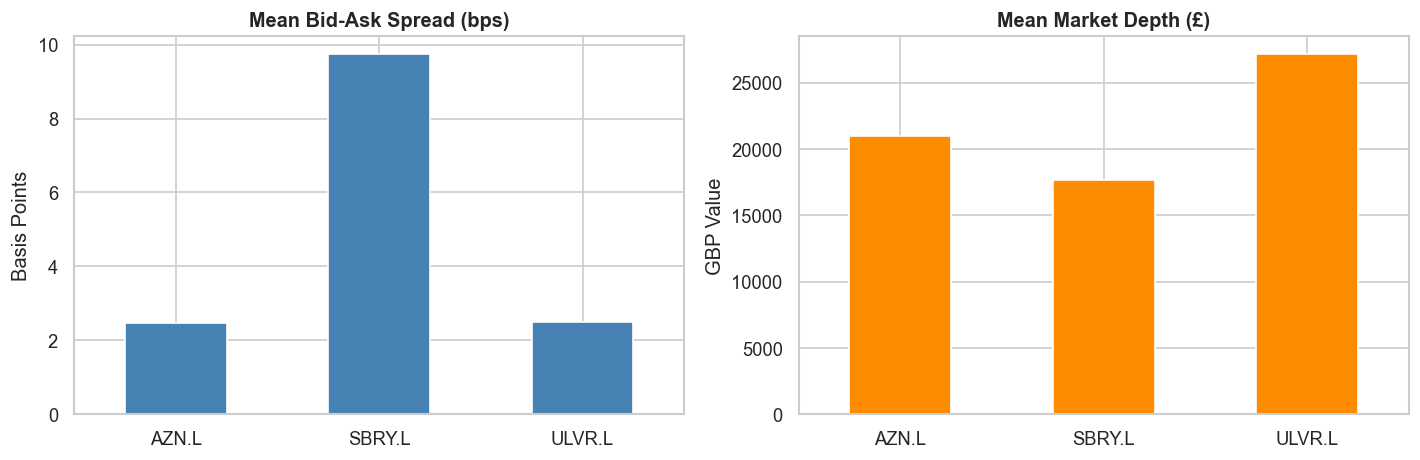

In [7]:
# ── Section 4: Average Liquidity Summary ────────────────────────────────────
summary = df_clean.groupby('Stock').agg(
    Mean_Spread_bps   = ('spread_bps',  'mean'),
    Median_Spread_bps = ('spread_bps',  'median'),
    Std_Spread_bps    = ('spread_bps',  'std'),
    Mean_Depth_GBP    = ('depth_gbp',   'mean'),
    Median_Depth_GBP  = ('depth_gbp',   'median'),
    N_obs             = ('midquote',     'count'),
).round(2)

print("=== Average Liquidity by Stock ===")
print(summary.T)

# Bar chart comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

summary['Mean_Spread_bps'].plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Mean Bid-Ask Spread (bps)', fontweight='bold')
axes[0].set_ylabel('Basis Points')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=0)

summary['Mean_Depth_GBP'].plot(kind='bar', ax=axes[1], color='darkorange', edgecolor='white')
axes[1].set_title('Mean Market Depth (£)', fontweight='bold')
axes[1].set_ylabel('GBP Value')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('liquidity_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

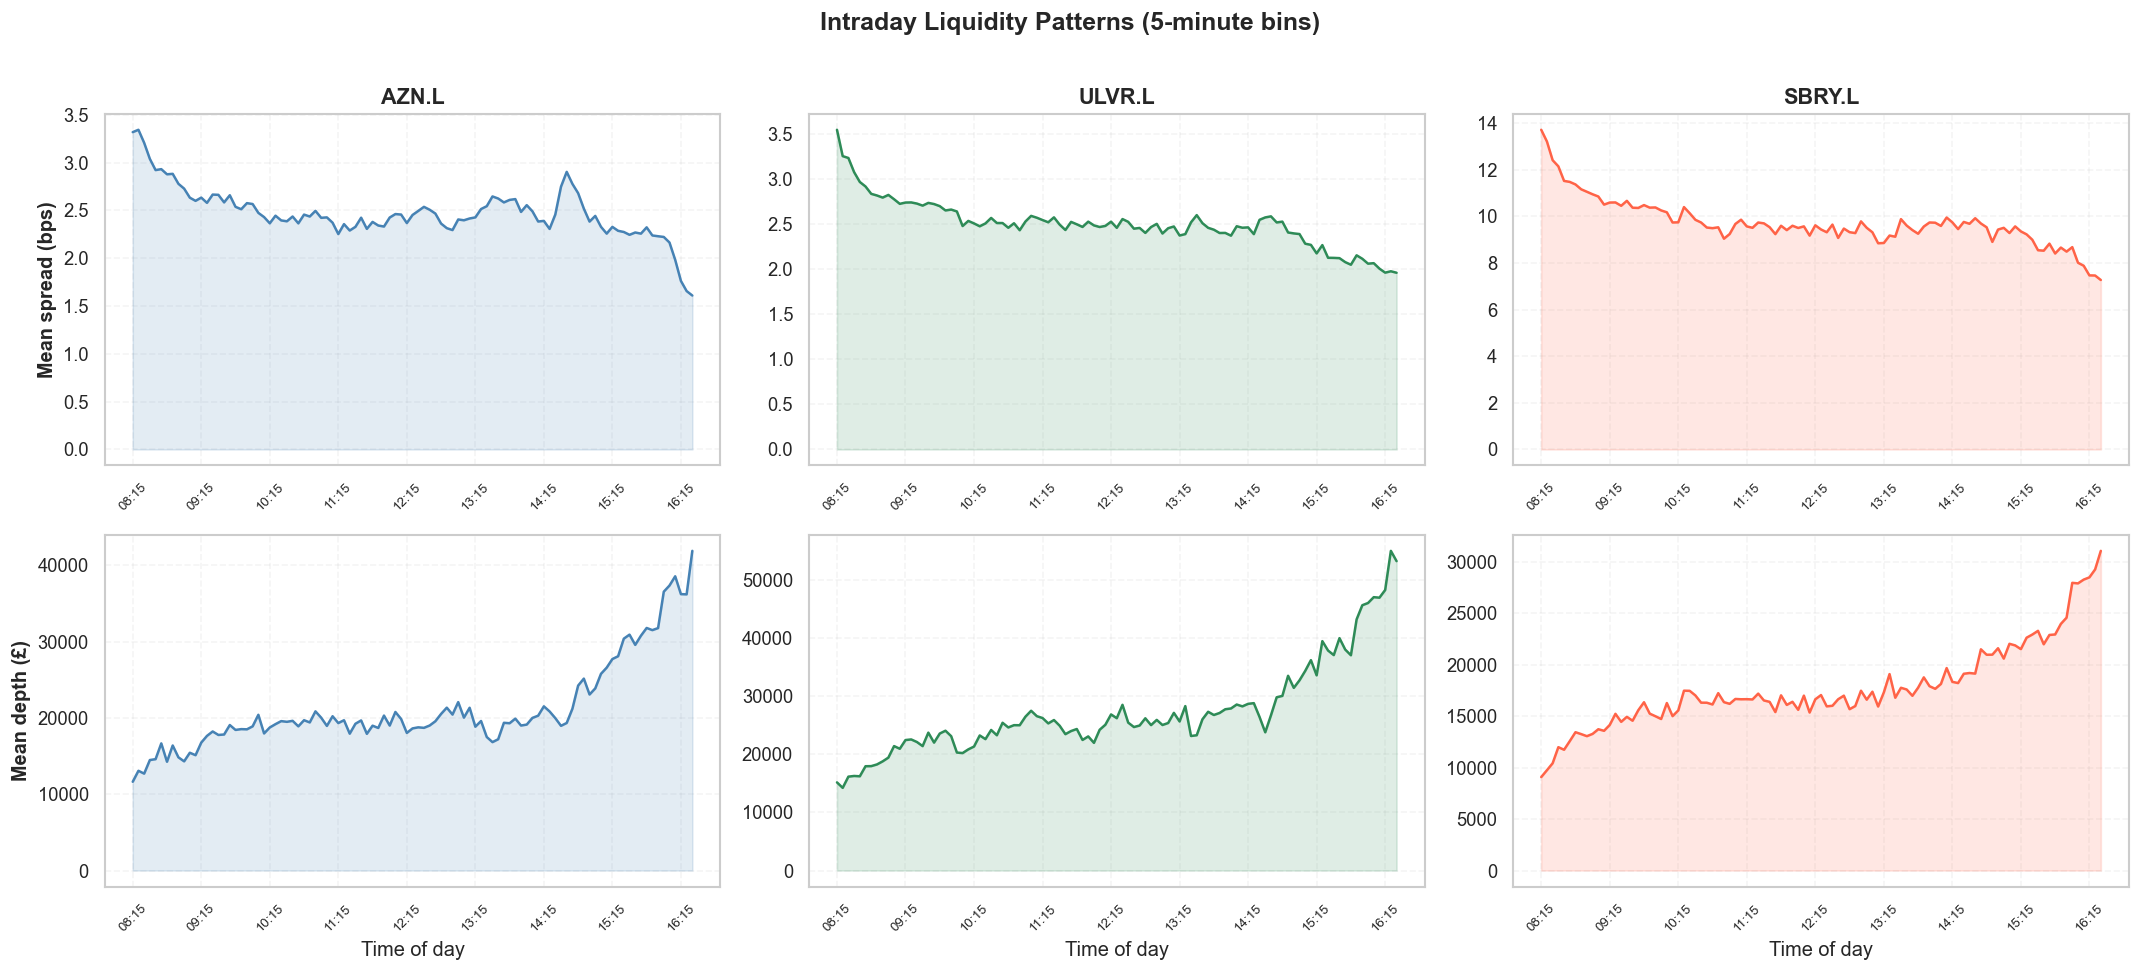

In [8]:
# ── Section 5: Intraday Liquidity Patterns (5-minute bins) ──────────────────
# Using 5-minute bins to capture opening/closing spikes that hourly averages mask.
intraday = (
    df_clean
    .groupby(['Stock', 'bin_5min'])
    .agg(mean_spread=('spread_bps', 'mean'),
         mean_depth=('depth_gbp',   'mean'))
    .reset_index()
)

# Convert bin (minutes since midnight) to HH:MM label
def min_to_hhmm(m):
    return f"{m//60:02d}:{m%60:02d}"

# Choose x-tick positions every 60 minutes (on the hour)
tick_bins   = list(range(495, 990, 60))   # 08:15 → 16:25 in 60-min steps
tick_labels = [min_to_hhmm(m) for m in tick_bins]

fig, axes = plt.subplots(2, len(selected_stocks), figsize=(6 * len(selected_stocks), 8))
colors = ['steelblue', 'seagreen', 'tomato']

for i, stock in enumerate(selected_stocks):
    data = intraday[intraday['Stock'] == stock].sort_values('bin_5min')
    c    = colors[i]

    # Spread
    axes[0, i].plot(data['bin_5min'], data['mean_spread'], color=c, linewidth=1.5)
    axes[0, i].fill_between(data['bin_5min'], data['mean_spread'], alpha=0.15, color=c)
    axes[0, i].set_title(f'{stock}', fontweight='bold', fontsize=13)
    axes[0, i].set_xticks(tick_bins)
    axes[0, i].set_xticklabels(tick_labels, rotation=45, fontsize=8)
    axes[0, i].set_ylabel('Mean spread (bps)' if i == 0 else '')
    axes[0, i].grid(True, alpha=0.2, linestyle='--')

    # Depth
    axes[1, i].plot(data['bin_5min'], data['mean_depth'], color=c, linewidth=1.5)
    axes[1, i].fill_between(data['bin_5min'], data['mean_depth'], alpha=0.15, color=c)
    axes[1, i].set_xlabel('Time of day')
    axes[1, i].set_xticks(tick_bins)
    axes[1, i].set_xticklabels(tick_labels, rotation=45, fontsize=8)
    axes[1, i].set_ylabel('Mean depth (£)' if i == 0 else '')
    axes[1, i].grid(True, alpha=0.2, linestyle='--')

axes[0, 0].set_ylabel('Mean spread (bps)', fontweight='bold')
axes[1, 0].set_ylabel('Mean depth (£)',    fontweight='bold')
fig.suptitle('Intraday Liquidity Patterns (5-minute bins)', fontsize=15, fontweight='bold', y=1.01)

plt.tight_layout()
plt.savefig('intraday_patterns.png', dpi=150, bbox_inches='tight')
plt.show()

In [9]:
# ── Section 6: Daily Aggregation ────────────────────────────────────────────
# Daily volatility = average of absolute minutely midquote returns within each day
daily = (
    df_clean
    .groupby(['Stock', 'date'])
    .agg(
        daily_spread     = ('spread_bps',      'mean'),
        daily_depth      = ('depth_gbp',        'mean'),
        daily_volatility = ('midquote_return',  lambda x: x.abs().mean()),
    )
    .dropna()
    .reset_index()
)

print("=== Daily Panel (first 10 rows) ===")
print(daily.head(10).to_string(index=False))

print("\n=== Daily Summary Stats by Stock ===")
print(daily.groupby('Stock')[['daily_spread', 'daily_depth', 'daily_volatility']].describe().round(4))

=== Daily Panel (first 10 rows) ===
Stock       date  daily_spread  daily_depth  daily_volatility
AZN.L 2026-01-05      2.757678 21009.281690          0.000398
AZN.L 2026-01-06      2.260888 16208.465245          0.000390
AZN.L 2026-01-07      2.519258 18728.745051          0.000456
AZN.L 2026-01-08      2.763357 25732.916925          0.000322
AZN.L 2026-01-09      2.559434 22917.404725          0.000339
AZN.L 2026-01-12      2.551901 20250.700122          0.000408
AZN.L 2026-01-13      2.576663 28735.793776          0.000327
AZN.L 2026-01-14      2.385463 25398.739939          0.000346
AZN.L 2026-01-15      2.218643 18466.904245          0.000336
AZN.L 2026-01-16      2.441000 25397.244465          0.000330

=== Daily Summary Stats by Stock ===
       daily_spread                                                            \
              count    mean     std     min     25%     50%      75%      max   
Stock                                                                           
A

=== Regression & Correlation Results: Daily Spread ~ Daily Volatility ===

AZN.L:
  Intercept   = 1.8369
  Slope (β)   = 1578.4641  (std err = 269.3754)
  R²          = 0.3564
  p-value     = 0.0000
  Pearson r   = 0.5970
  Spearman ρ  = 0.4609  (p = 0.0001)

ULVR.L:
  Intercept   = 2.1121
  Slope (β)   = 1153.1023  (std err = 447.6722)
  R²          = 0.0967
  p-value     = 0.0124
  Pearson r   = 0.3109
  Spearman ρ  = 0.3187  (p = 0.0103)

SBRY.L:
  Intercept   = 8.5754
  Slope (β)   = 3351.2345  (std err = 830.9109)
  R²          = 0.2078
  p-value     = 0.0002
  Pearson r   = 0.4559
  Spearman ρ  = 0.3588  (p = 0.0036)



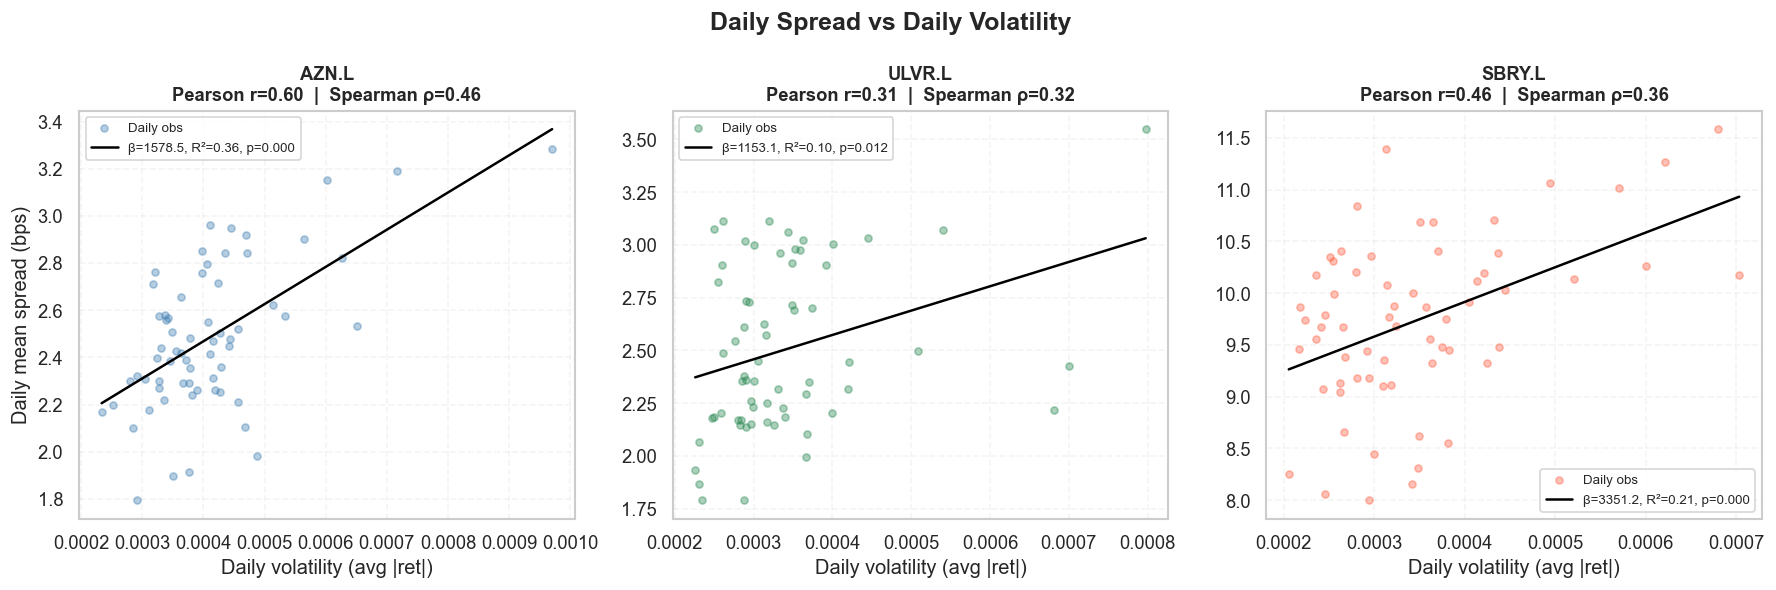

In [10]:
# ── Section 7: Regression & Correlation – Daily Spread vs Daily Volatility ───
fig, axes = plt.subplots(1, len(selected_stocks), figsize=(5 * len(selected_stocks), 5))
colors = ['steelblue', 'seagreen', 'tomato']

print("=== Regression & Correlation Results: Daily Spread ~ Daily Volatility ===\n")

for i, stock in enumerate(selected_stocks):
    d = daily[daily['Stock'] == stock].dropna(subset=['daily_volatility', 'daily_spread'])
    x = d['daily_volatility'].values
    y = d['daily_spread'].values

    slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
    pearson_r  = np.corrcoef(x, y)[0, 1]
    spearman_r, spearman_p = stats.spearmanr(x, y)

    print(f"{stock}:")
    print(f"  Intercept   = {intercept:.4f}")
    print(f"  Slope (β)   = {slope:.4f}  (std err = {std_err:.4f})")
    print(f"  R²          = {r_value**2:.4f}")
    print(f"  p-value     = {p_value:.4f}")
    print(f"  Pearson r   = {pearson_r:.4f}")
    print(f"  Spearman ρ  = {spearman_r:.4f}  (p = {spearman_p:.4f})\n")

    axes[i].scatter(x, y, alpha=0.4, s=18, color=colors[i], label='Daily obs')
    x_line = np.linspace(x.min(), x.max(), 200)
    axes[i].plot(x_line, intercept + slope * x_line, color='black', linewidth=1.5,
                 label=f'β={slope:.1f}, R²={r_value**2:.2f}, p={p_value:.3f}')
    axes[i].set_title(
        f'{stock}\nPearson r={pearson_r:.2f}  |  Spearman ρ={spearman_r:.2f}',
        fontweight='bold', fontsize=11)
    axes[i].set_xlabel('Daily volatility (avg |ret|)')
    axes[i].set_ylabel('Daily mean spread (bps)' if i == 0 else '')
    axes[i].legend(fontsize=8)
    axes[i].grid(True, alpha=0.2, linestyle='--')

fig.suptitle('Daily Spread vs Daily Volatility', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('spread_vs_volatility.png', dpi=150, bbox_inches='tight')
plt.show()

=== Correlation: Daily Depth ~ Daily Volatility ===

AZN.L:
  Slope (β)  = -20977503.76  (p = 0.0003)
  R²         = 0.1959
  Pearson r  = -0.4426

ULVR.L:
  Slope (β)  = -9631323.78  (p = 0.6209)
  R²         = 0.0040
  Pearson r  = -0.0630

SBRY.L:
  Slope (β)  = -12604661.87  (p = 0.0057)
  R²         = 0.1167
  Pearson r  = -0.3416



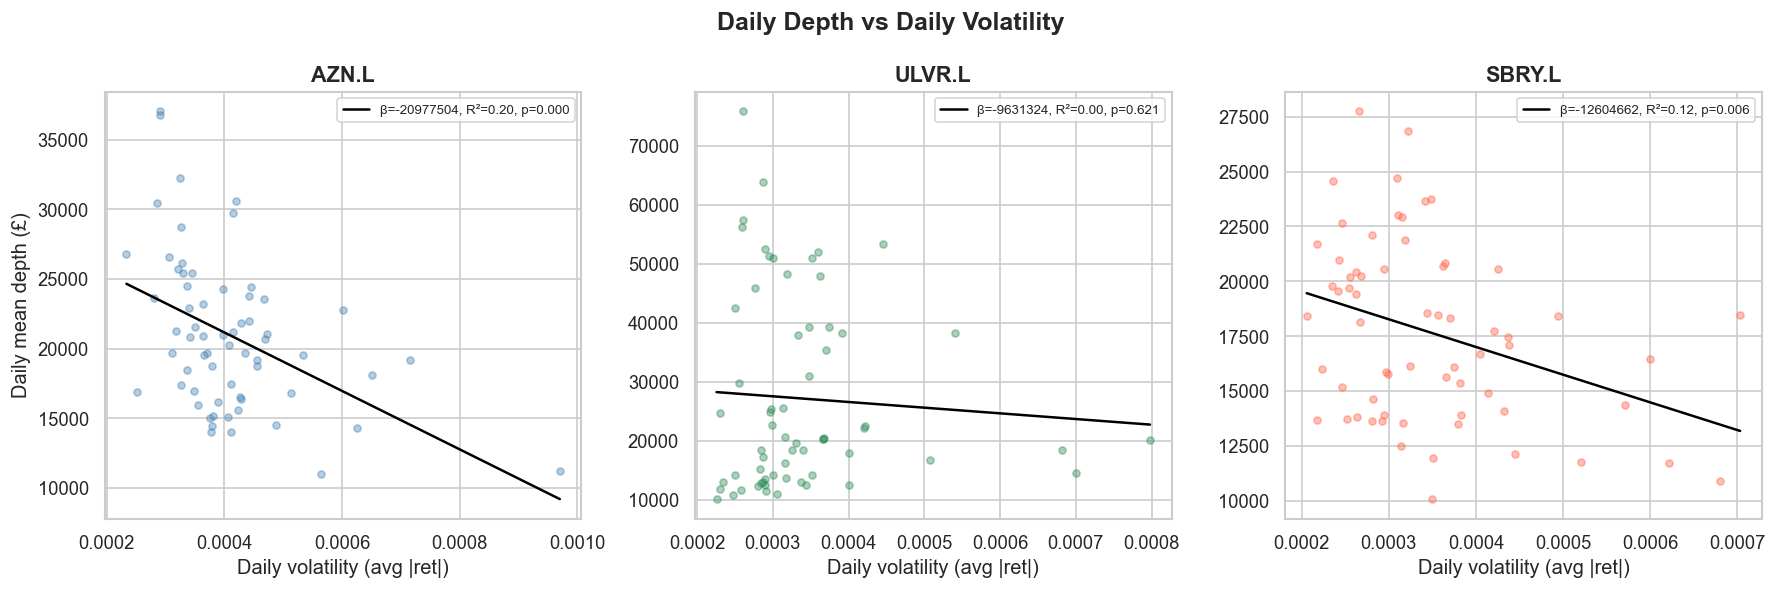

In [11]:
# ── Section 8: Correlation – Daily Depth vs Daily Volatility ────────────────
print("=== Correlation: Daily Depth ~ Daily Volatility ===\n")

fig, axes = plt.subplots(1, len(selected_stocks), figsize=(5 * len(selected_stocks), 5))
colors = ['steelblue', 'seagreen', 'tomato']

for i, stock in enumerate(selected_stocks):
    d = daily[daily['Stock'] == stock].dropna(subset=['daily_volatility', 'daily_depth'])
    x = d['daily_volatility'].values
    y = d['daily_depth'].values

    slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
    pearson_r = np.corrcoef(x, y)[0, 1]

    print(f"{stock}:")
    print(f"  Slope (β)  = {slope:.2f}  (p = {p_value:.4f})")
    print(f"  R²         = {r_value**2:.4f}")
    print(f"  Pearson r  = {pearson_r:.4f}\n")

    axes[i].scatter(x, y, alpha=0.4, s=18, color=colors[i])
    x_line = np.linspace(x.min(), x.max(), 200)
    axes[i].plot(x_line, intercept + slope * x_line, color='black', linewidth=1.5,
                 label=f'β={slope:.0f}, R²={r_value**2:.2f}, p={p_value:.3f}')
    axes[i].set_title(stock, fontweight='bold', fontsize=13)
    axes[i].set_xlabel('Daily volatility (avg |ret|)')
    axes[i].set_ylabel('Daily mean depth (£)' if i == 0 else '')
    axes[i].legend(fontsize=8)

fig.suptitle('Daily Depth vs Daily Volatility', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('depth_vs_volatility.png', dpi=150, bbox_inches='tight')
plt.show()

# ═══════════════════════════════════════════════════════════════════
# PART 2 — Portfolio Analysis
# ═══════════════════════════════════════════════════════════════════
# Requires: SMM921_PF_DATA_2026.xlsx in the same folder as this notebook.
# Download it from Moodle, then run all cells below.

In [12]:
# ── P1: Load Data & Create Returns ──────────────────────────────────────────
DATA_PATH = '../data/SMM921_PF_DATA_2026.xlsx'

prices = pd.read_excel(DATA_PATH, index_col=0, parse_dates=True)
prices.index = pd.to_datetime(prices.index)
prices.sort_index(inplace=True)

print(f"Shape: {prices.shape}  ({prices.shape[0]} months × {prices.shape[1]} countries)")
print(f"Date range: {prices.index[0].date()} → {prices.index[-1].date()}")
print(f"\nCountries: {list(prices.columns)}")
print(prices.head())

# Monthly log returns (percentage changes from index levels)
returns = prices.pct_change().dropna()

# World return = equal-weighted average across all countries each month
returns['World'] = returns.mean(axis=1)

print(f"\nReturns shape: {returns.shape}")
print(returns.head())

Shape: (241, 34)  (241 months × 34 countries)
Date range: 2006-05-21 → 2026-05-21

Countries: ['USA', 'UK', 'SWITZERLAND', 'JAPAN', 'CANADA', 'AUSTRALIA', 'NEW ZEALAND', 'SWEDEN', 'NORWAY', 'DENMARK', 'GERMANY', 'ITALY', 'FRANCE', 'NETHERLANDS', 'BELGIUM', 'FINLAND', 'IRELAND', 'HONG KONG', 'SOUTH AFRICA', 'SINGAPORE', 'AUSTRIA', 'INDIA', 'INDONESIA', 'MALAYSIA', 'MEXICO', 'PHILIPPINES', 'POLAND', 'PORTUGAL', 'KOREA', 'SPAIN', 'TAIWAN', 'THAILAND', 'BRAZIL', 'ISRAEL']
                 USA        UK  SWITZERLAND     JAPAN    CANADA  AUSTRALIA  \
Date                                                                         
2006-05-21  3989.266  5960.651     7974.317  5578.067  4257.831   3082.861   
2006-06-21  3941.876  5887.423     7709.363  4992.214  4160.302   2899.801   
2006-07-21  3898.953  5991.802     7898.940  5016.559  4170.239   3007.304   
2006-08-21  4088.154  6365.330     8445.406  5396.046  4523.199   3135.845   
2006-09-21  4161.212  6369.264     8585.642  5218.764  4299

=== Country Performance Summary (sorted by Sharpe) ===
              Ann. Mean (%)  Ann. Std (%)  Sharpe   Beta
USA                   12.48         17.62   0.708  0.718
TAIWAN                15.89         24.16   0.658  0.903
SWITZERLAND            9.55         17.67   0.540  0.774
NETHERLANDS           12.05         23.66   0.509  1.044
DENMARK               11.51         24.00   0.479  0.955
KOREA                 13.75         29.14   0.472  1.189
CANADA                10.11         22.16   0.456  0.974
SINGAPORE              9.62         21.74   0.443  0.953
SWEDEN                11.15         25.80   0.432  1.161
THAILAND              10.22         24.24   0.422  0.897
HONG KONG              8.57         21.18   0.404  0.844
AUSTRALIA              9.78         24.26   0.403  1.086
INDIA                 10.48         26.09   0.402  1.007
GERMANY                9.29         23.58   0.394  1.072
ISRAEL                 8.01         20.56   0.390  0.679
MALAYSIA               6.62      

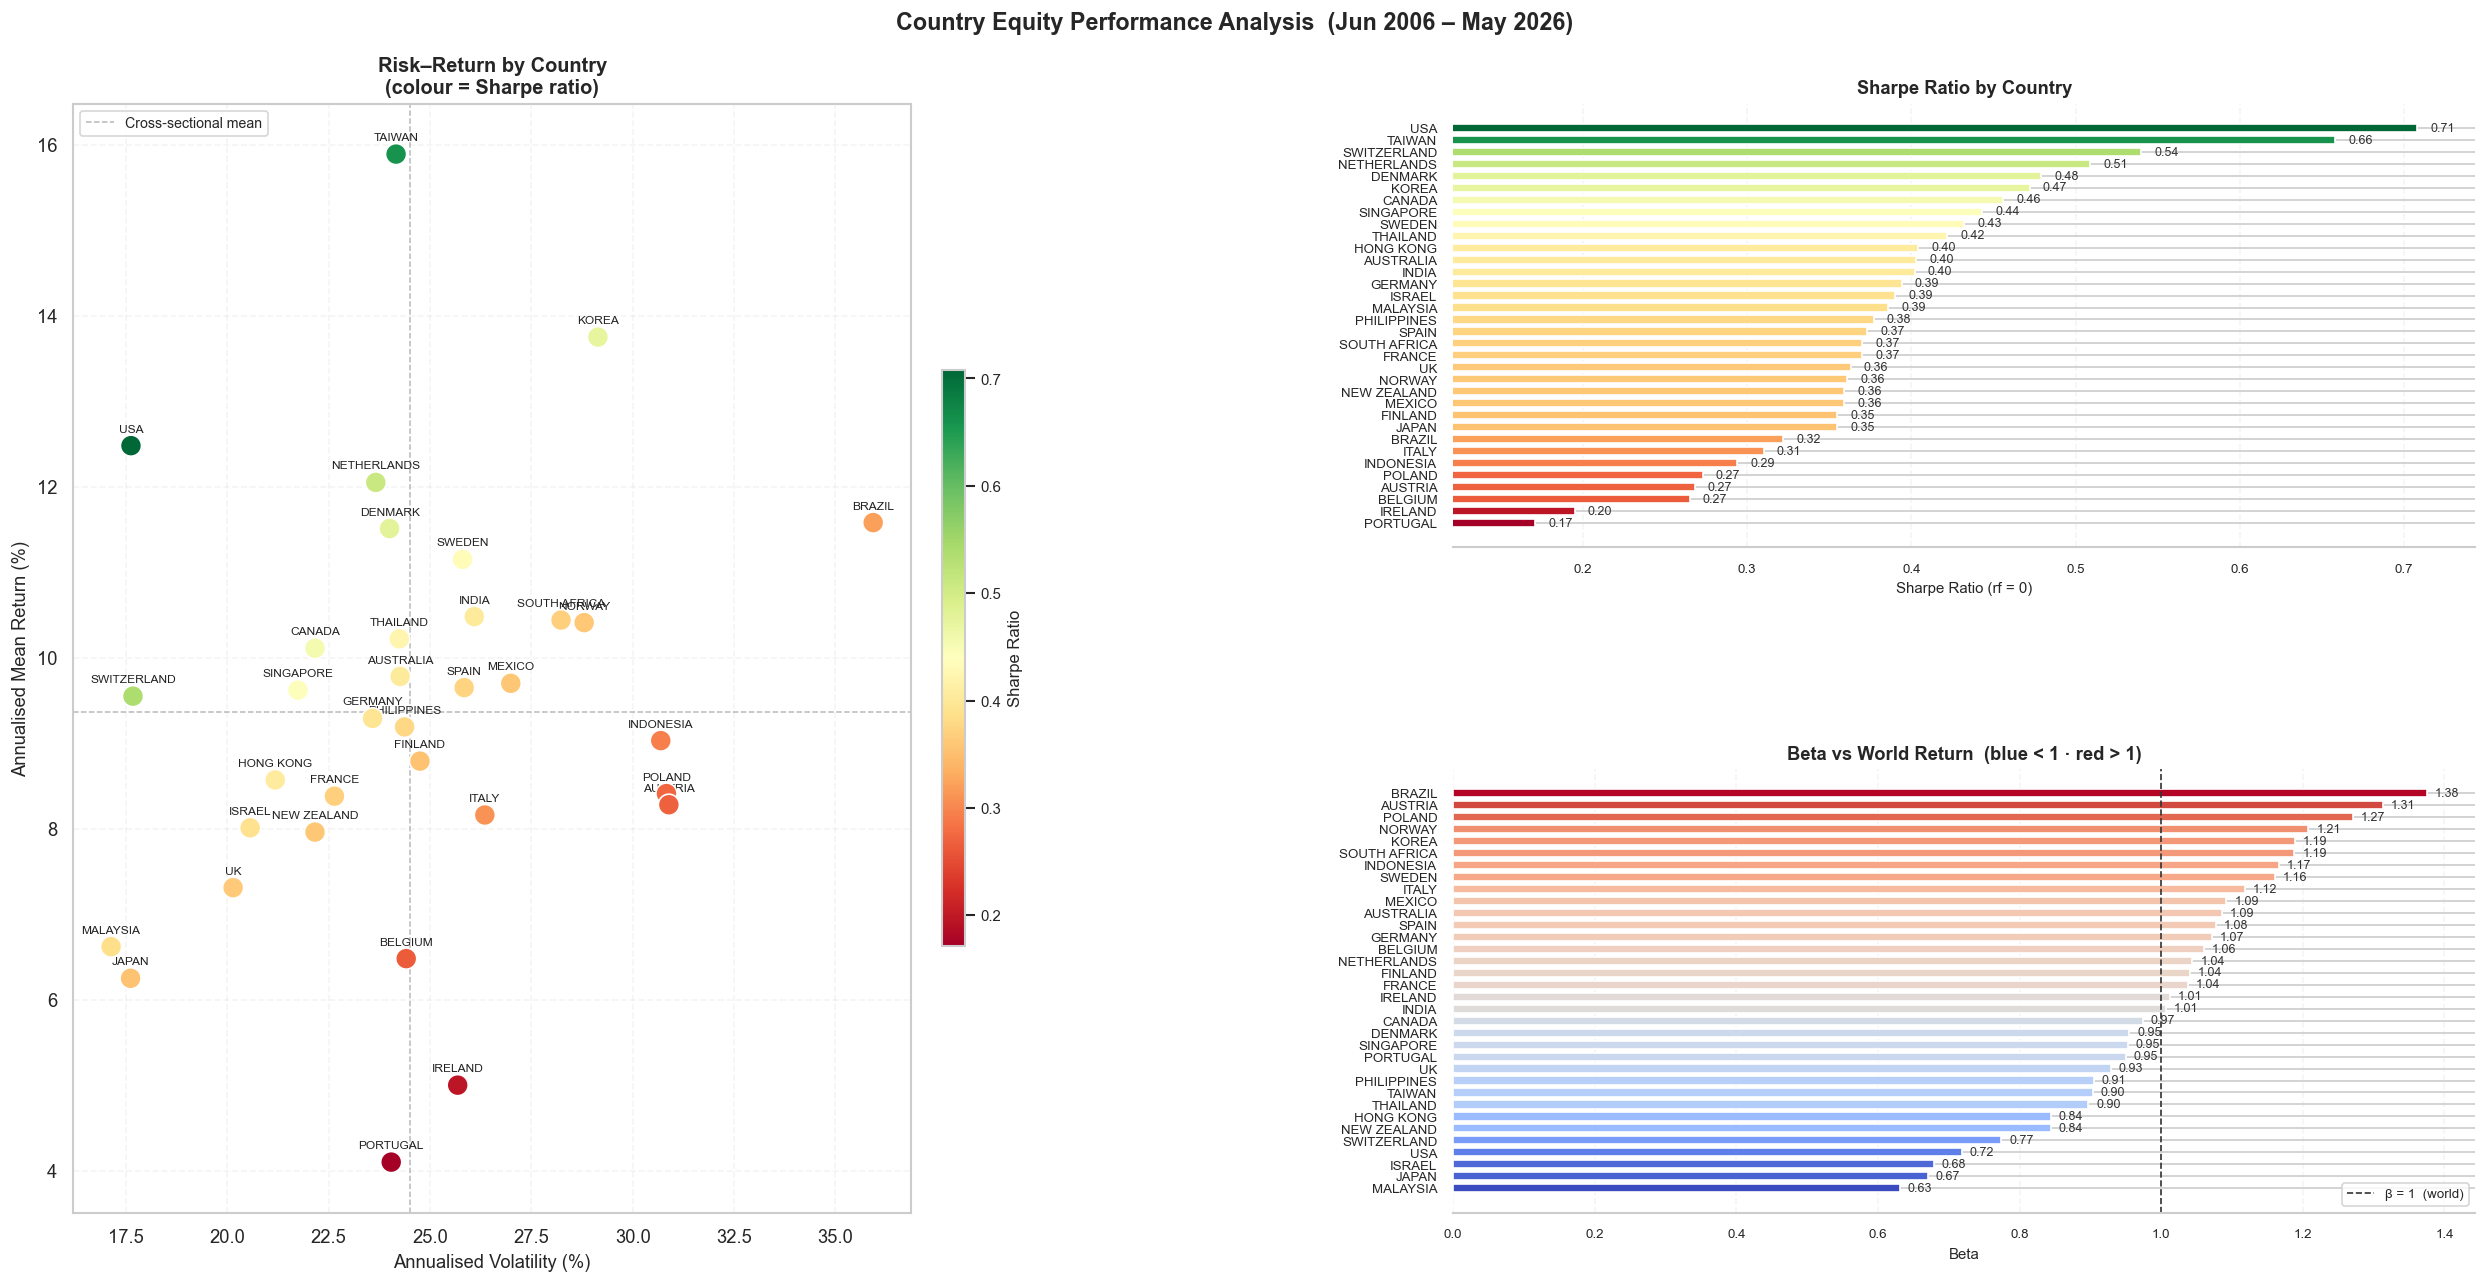

In [13]:
# ── P2: Performance Analysis — Mean, Std, Sharpe, Beta ──────────────────────
import matplotlib.colors as mcolors

country_rets = returns.drop(columns='World')
world_ret    = returns['World']

ann_mean = country_rets.mean() * 12
ann_std  = country_rets.std()  * np.sqrt(12)
sharpe   = ann_mean / ann_std

beta = country_rets.apply(
    lambda r: np.cov(r, world_ret)[0, 1] / np.var(world_ret)
)

perf = pd.DataFrame({
    'Ann. Mean (%)': (ann_mean * 100).round(2),
    'Ann. Std (%)':  (ann_std  * 100).round(2),
    'Sharpe':         sharpe.round(3),
    'Beta':           beta.round(3),
}).sort_values('Sharpe', ascending=False)

print("=== Country Performance Summary (sorted by Sharpe) ===")
print(perf.to_string())

# ── Figure layout: risk-return scatter (left) | Sharpe + Beta bars (right) ──
fig = plt.figure(figsize=(22, 11))
gs  = fig.add_gridspec(2, 2, wspace=0.35, hspace=0.5,
                        left=0.06, right=0.97, top=0.91, bottom=0.07)

ax_sc  = fig.add_subplot(gs[:, 0])
ax_sr  = fig.add_subplot(gs[0, 1])
ax_b   = fig.add_subplot(gs[1, 1])

cmap_sr = plt.cm.RdYlGn
norm_sr = mcolors.Normalize(vmin=perf['Sharpe'].min(), vmax=perf['Sharpe'].max())

# ── Panel 1: Risk–Return scatter ─────────────────────────────────────────────
x, y = perf['Ann. Std (%)'], perf['Ann. Mean (%)']
sc = ax_sc.scatter(x, y, c=perf['Sharpe'], cmap=cmap_sr, norm=norm_sr,
                   s=160, zorder=5, edgecolors='white', linewidth=1.0)

for country, row in perf.iterrows():
    ax_sc.annotate(country,
                   xy=(row['Ann. Std (%)'], row['Ann. Mean (%)']),
                   xytext=(0, 7), textcoords='offset points',
                   fontsize=7.2, ha='center', va='bottom', color='#222222',
                   fontweight='medium')

ax_sc.axhline(y.mean(), color='#888888', lw=0.9, ls='--', alpha=0.6, label='Cross-sectional mean')
ax_sc.axvline(x.mean(), color='#888888', lw=0.9, ls='--', alpha=0.6)

cbar = fig.colorbar(sc, ax=ax_sc, shrink=0.52, pad=0.03, aspect=25)
cbar.set_label('Sharpe Ratio', fontsize=10)
cbar.ax.tick_params(labelsize=9)

ax_sc.set_xlabel('Annualised Volatility (%)', fontsize=11)
ax_sc.set_ylabel('Annualised Mean Return (%)', fontsize=11)
ax_sc.set_title('Risk–Return by Country\n(colour = Sharpe ratio)', fontweight='bold', fontsize=12)
ax_sc.grid(True, alpha=0.2, linestyle='--')
ax_sc.legend(fontsize=8.5, loc='upper left')

# ── Panel 2: Sharpe ranking ───────────────────────────────────────────────────
sharpe_s   = perf['Sharpe'].sort_values()
bar_colors = [cmap_sr(norm_sr(v)) for v in sharpe_s]

bars = ax_sr.barh(range(len(sharpe_s)), sharpe_s.values,
                  color=bar_colors, edgecolor='white', height=0.68)
ax_sr.set_yticks(range(len(sharpe_s)))
ax_sr.set_yticklabels(sharpe_s.index, fontsize=7.8)
ax_sr.axvline(0, color='#333333', lw=1.0, ls='--')

x_pad = (sharpe_s.max() - sharpe_s.min()) * 0.015
for bar, val in zip(bars, sharpe_s.values):
    ax_sr.text(val + x_pad, bar.get_y() + bar.get_height() / 2,
               f'{val:.2f}', va='center', ha='left', fontsize=7.5, color='#333333')

ax_sr.set_xlim(left=sharpe_s.min() - 0.05)
ax_sr.set_title('Sharpe Ratio by Country', fontweight='bold', fontsize=11)
ax_sr.set_xlabel('Sharpe Ratio (rf = 0)', fontsize=9)
ax_sr.grid(axis='x', alpha=0.2, linestyle='--')
ax_sr.tick_params(labelsize=8)
sns.despine(ax=ax_sr, left=True)

# ── Panel 3: Beta ranking ─────────────────────────────────────────────────────
beta_s    = perf['Beta'].sort_values()
norm_b    = mcolors.TwoSlopeNorm(vmin=beta_s.min(), vcenter=1.0, vmax=beta_s.max())
b_colors  = [plt.cm.coolwarm(norm_b(v)) for v in beta_s.values]

bars_b = ax_b.barh(range(len(beta_s)), beta_s.values,
                   color=b_colors, edgecolor='white', height=0.68)
ax_b.set_yticks(range(len(beta_s)))
ax_b.set_yticklabels(beta_s.index, fontsize=7.8)
ax_b.axvline(1.0, color='#333333', lw=1.0, ls='--', label='β = 1  (world)')

x_pad_b = (beta_s.max() - beta_s.min()) * 0.015
for bar, val in zip(bars_b, beta_s.values):
    ax_b.text(val + x_pad_b, bar.get_y() + bar.get_height() / 2,
              f'{val:.2f}', va='center', ha='left', fontsize=7.5, color='#333333')

ax_b.set_title('Beta vs World Return  (blue < 1 · red > 1)', fontweight='bold', fontsize=11)
ax_b.set_xlabel('Beta', fontsize=9)
ax_b.grid(axis='x', alpha=0.2, linestyle='--')
ax_b.tick_params(labelsize=8)
ax_b.legend(fontsize=8, loc='lower right')
sns.despine(ax=ax_b, left=True)

date_range = f"{returns.index[0].strftime('%b %Y')} – {returns.index[-1].strftime('%b %Y')}"
fig.suptitle(f'Country Equity Performance Analysis  ({date_range})',
             fontsize=14, fontweight='bold')

plt.savefig('performance_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

In [14]:
# ── P3: Momentum Signal Construction ────────────────────────────────────────
# Signal at time t = cumulative return over the 11 months t-12 to t-2
# (12 months leading up to t, excluding the most recent month t-1)
# Implementation: 11-month rolling product of returns, then shift 1 period forward

def cum_return(x):
    return (1 + x).prod() - 1

momentum_raw = (
    country_rets
    .rolling(window=11)
    .apply(cum_return, raw=True)
    .shift(1)       # at month t, use signal computed through t-2
)

print(f"Momentum signal shape: {momentum_raw.shape}")
print(f"First valid row: {momentum_raw.dropna(how='all').index[0].date()}")
print(momentum_raw.head(16).to_string())  # NaNs until window fills

Momentum signal shape: (240, 34)
First valid row: 2007-05-21
                 USA        UK  SWITZERLAND     JAPAN    CANADA  AUSTRALIA  NEW ZEALAND    SWEDEN    NORWAY   DENMARK   GERMANY     ITALY    FRANCE  NETHERLANDS   BELGIUM   FINLAND   IRELAND  HONG KONG  SOUTH AFRICA  SINGAPORE   AUSTRIA     INDIA  INDONESIA  MALAYSIA    MEXICO  PHILIPPINES    POLAND  PORTUGAL     KOREA     SPAIN    TAIWAN  THAILAND    BRAZIL    ISRAEL
Date                                                                                                                                                                                                                                                                                                                                                                              
2006-06-21       NaN       NaN          NaN       NaN       NaN        NaN          NaN       NaN       NaN       NaN       NaN       NaN       NaN          NaN       NaN       NaN       NaN       

In [15]:
# ── P4: 5 Momentum-Sorted Portfolios + HML ──────────────────────────────────
n_portfolios = 5
port_returns = {f'P{i+1}': [] for i in range(n_portfolios)}
port_dates   = []

valid_idx = momentum_raw.dropna(how='all').index

for t in valid_idx:
    signal = momentum_raw.loc[t].dropna()
    if len(signal) < n_portfolios:
        continue
    actual_ret = country_rets.loc[t, signal.index]  # same-month returns

    # Rank into quintiles (qcut handles ties gracefully)
    labels = pd.qcut(signal, q=n_portfolios, labels=False, duplicates='drop')
    for q in range(n_portfolios):
        members = labels[labels == q].index
        port_returns[f'P{q+1}'].append(actual_ret[members].mean())
    port_dates.append(t)

port_df = pd.DataFrame(port_returns, index=port_dates)
port_df['HML'] = port_df['P5'] - port_df['P1']   # high minus low momentum

print(f"Portfolio returns shape: {port_df.shape}")
print(port_df.head())

Portfolio returns shape: (229, 6)
                  P1        P2        P3        P4        P5       HML
2007-05-21  0.042308  0.022282  0.006342  0.034970  0.036034 -0.006274
2007-06-21  0.010008  0.020460  0.019987  0.012482  0.038216  0.028208
2007-07-21  0.041782  0.037155  0.063169  0.051886  0.054058  0.012276
2007-08-21 -0.089294 -0.095821 -0.106229 -0.141039 -0.163609 -0.074315
2007-09-21  0.052605  0.118273  0.115720  0.142216  0.155137  0.102531


=== Momentum Portfolio Statistics ===
           Ann. Mean (%)  Ann. Std (%)  Sharpe  Max Drawdown (%)  Beta vs World
Portfolio                                                                      
P1                  8.26         23.48   0.352            -61.25          1.074
P2                  7.33         21.89   0.335            -60.77          1.036
P3                  7.89         21.41   0.369            -55.10          1.008
P4                  9.34         21.10   0.443            -59.03          0.990
P5                  8.33         20.20   0.413            -58.17          0.914
HML                 0.07         13.82   0.005            -59.33         -0.160


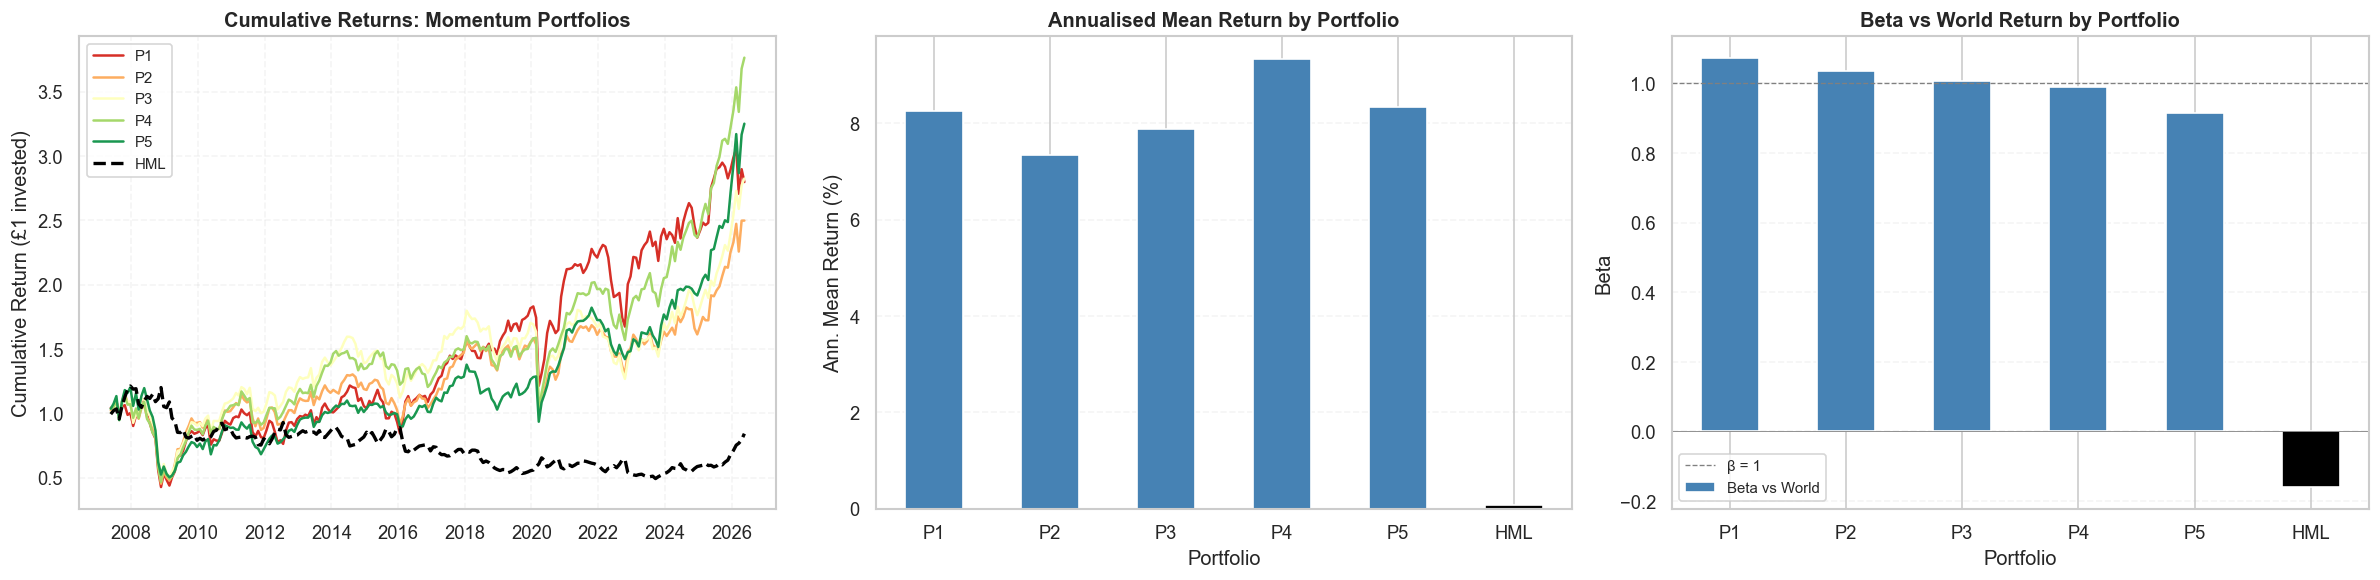

In [16]:
# ── P5: Momentum Portfolio Summary Stats, Plots & Performance ───────────────
def portfolio_stats(ret_series, benchmark=None):
    ann_m  = ret_series.mean() * 12
    ann_s  = ret_series.std()  * np.sqrt(12)
    sharpe = ann_m / ann_s
    cum    = (1 + ret_series).cumprod()
    max_dd = (cum / cum.cummax() - 1).min()
    result = {
        'Ann. Mean (%)':   round(ann_m  * 100, 2),
        'Ann. Std (%)':    round(ann_s  * 100, 2),
        'Sharpe':           round(sharpe, 3),
        'Max Drawdown (%)': round(max_dd * 100, 2),
    }
    if benchmark is not None:
        aligned = benchmark.reindex(ret_series.index).dropna()
        r_align = ret_series.reindex(aligned.index)
        b = np.cov(r_align, aligned)[0, 1] / np.var(aligned)
        result['Beta vs World'] = round(b, 3)
    return result

# World return aligned to portfolio dates
world_port = world_ret.reindex(port_df.index)

stats_list = []
for col in port_df.columns:
    s = portfolio_stats(port_df[col], benchmark=world_port)
    s['Portfolio'] = col
    stats_list.append(s)

port_stats = pd.DataFrame(stats_list).set_index('Portfolio')
print("=== Momentum Portfolio Statistics ===")
print(port_stats.to_string())

# ── Plots ────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# Cumulative returns
cum_rets = (1 + port_df).cumprod()
colors_p = plt.cm.RdYlGn(np.linspace(0.1, 0.9, n_portfolios))
for i, col in enumerate([f'P{i+1}' for i in range(n_portfolios)]):
    axes[0].plot(cum_rets.index, cum_rets[col], label=col, color=colors_p[i], linewidth=1.5)
axes[0].plot(cum_rets.index, cum_rets['HML'], label='HML', color='black', linewidth=2, linestyle='--')
axes[0].set_title('Cumulative Returns: Momentum Portfolios', fontweight='bold')
axes[0].set_ylabel('Cumulative Return (£1 invested)')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.2, linestyle='--')

# Annualised mean return
port_order = [f'P{i+1}' for i in range(n_portfolios)] + ['HML']
bar_cols   = ['steelblue'] * n_portfolios + ['black']
port_stats.loc[port_order, 'Ann. Mean (%)'].plot(
    kind='bar', ax=axes[1], color=bar_cols, edgecolor='white')
axes[1].axhline(0, color='gray', linewidth=0.8)
axes[1].set_title('Annualised Mean Return by Portfolio', fontweight='bold')
axes[1].set_ylabel('Ann. Mean Return (%)')
axes[1].tick_params(axis='x', rotation=0)
axes[1].grid(axis='y', alpha=0.2, linestyle='--')

# Beta vs world
port_stats.loc[port_order, 'Beta vs World'].plot(
    kind='bar', ax=axes[2], color=bar_cols, edgecolor='white')
axes[2].axhline(1, color='gray', linewidth=0.8, linestyle='--', label='β = 1')
axes[2].axhline(0, color='gray', linewidth=0.5)
axes[2].set_title('Beta vs World Return by Portfolio', fontweight='bold')
axes[2].set_ylabel('Beta')
axes[2].tick_params(axis='x', rotation=0)
axes[2].legend(fontsize=9)
axes[2].grid(axis='y', alpha=0.2, linestyle='--')

plt.tight_layout()
plt.savefig('momentum_portfolios.png', dpi=150, bbox_inches='tight')
plt.show()

In [17]:
# ── P6: MV Optimisation — Alpha Construction (Grinold-Kahn) ─────────────────
# alpha_i = IC * sigma_cs * z_i   (Grinold-Kahn fundamental law)
# IC       = 0.02  (given)
# sigma_cs = cross-sectional mean of country vols over last 60 months (same for all)
# z_i      = cross-sectional z-score of momentum signal
#
# Constrained MV solution (weights sum to 1) via Lagrangian:
#   w = (1/lambda) * Sigma^{-1} * (alpha - theta * 1)
#   theta = (1' Sigma^{-1} alpha - lambda) / (1' Sigma^{-1} 1)

IC     = 0.02
LAMBDA = 4
WINDOW = 60
START  = 60

ret_idx = country_rets.index
opt_returns_sample = []
opt_dates          = []

def mv_weights(Sigma_inv, alpha_vec, lam):
    """Lagrangian MV weights constrained to sum to 1."""
    ones      = np.ones(len(alpha_vec))
    Si_a      = Sigma_inv @ alpha_vec
    Si_1      = Sigma_inv @ ones
    theta     = (ones @ Si_a - lam) / (ones @ Si_1)
    w         = (1 / lam) * Sigma_inv @ (alpha_vec - theta * ones)
    return w

for t in range(START, len(ret_idx) - 1):
    hist = country_rets.iloc[t - WINDOW: t]
    sig  = momentum_raw.iloc[t]
    if sig.isna().any():
        continue

    vols     = hist.std()
    sigma_cs = vols.mean()
    z        = (sig - sig.mean()) / sig.std()
    alpha    = (IC * sigma_cs * z).values

    Sigma = hist.cov().values
    try:
        Sigma_inv = np.linalg.inv(Sigma)
    except np.linalg.LinAlgError:
        continue

    w      = mv_weights(Sigma_inv, alpha, LAMBDA)
    r_next = country_rets.iloc[t + 1].values
    opt_returns_sample.append(float(w @ r_next))
    opt_dates.append(ret_idx[t + 1])

opt_sample = pd.Series(opt_returns_sample, index=opt_dates, name='MV_Sample')
print(f"MV (sample covariance) returns: {len(opt_sample)} months")
print(opt_sample.describe())
print(f"\nAnn. Mean: {opt_sample.mean()*12*100:.2f}%  |  Ann. Std: {opt_sample.std()*np.sqrt(12)*100:.2f}%  |  Sharpe: {opt_sample.mean()*12 / (opt_sample.std()*np.sqrt(12)):.3f}")

MV (sample covariance) returns: 179 months
count    179.000000
mean       0.012094
std        0.139094
min       -0.419027
25%       -0.074504
50%        0.012694
75%        0.091253
max        0.383481
Name: MV_Sample, dtype: float64

Ann. Mean: 14.51%  |  Ann. Std: 48.18%  |  Sharpe: 0.301


In [18]:
# ── P7: MV Optimisation — Robust (Constant Correlation) Covariance ──────────
# Replace all off-diagonal covariances with sigma_i * sigma_j * rho_bar,
# where rho_bar = mean of all pairwise correlations from the sample matrix.
# Variances are left unchanged.

def constant_corr_cov(hist_df):
    Sigma_s = hist_df.cov().values
    stds    = np.sqrt(np.diag(Sigma_s))
    D_inv   = np.diag(1.0 / stds)
    C       = D_inv @ Sigma_s @ D_inv           # correlation matrix
    N       = C.shape[0]
    mask    = ~np.eye(N, dtype=bool)
    rho_bar = C[mask].mean()                    # mean off-diagonal correlation
    C_const = np.full((N, N), rho_bar)
    np.fill_diagonal(C_const, 1.0)
    D       = np.diag(stds)
    return D @ C_const @ D

opt_returns_robust = []

for t in range(START, len(ret_idx) - 1):
    hist = country_rets.iloc[t - WINDOW: t]
    sig  = momentum_raw.iloc[t]
    if sig.isna().any():
        continue

    vols     = hist.std()
    sigma_cs = vols.mean()
    z        = (sig - sig.mean()) / sig.std()
    alpha    = (IC * sigma_cs * z).values

    Sigma_r = constant_corr_cov(hist)
    try:
        Sigma_r_inv = np.linalg.inv(Sigma_r)
    except np.linalg.LinAlgError:
        continue

    w      = mv_weights(Sigma_r_inv, alpha, LAMBDA)
    r_next = country_rets.iloc[t + 1].values
    opt_returns_robust.append(float(w @ r_next))

opt_robust = pd.Series(opt_returns_robust, index=opt_dates, name='MV_Robust')
print(f"MV (robust covariance) returns: {len(opt_robust)} months")
print(opt_robust.describe())
print(f"\nAnn. Mean: {opt_robust.mean()*12*100:.2f}%  |  Ann. Std: {opt_robust.std()*np.sqrt(12)*100:.2f}%  |  Sharpe: {opt_robust.mean()*12 / (opt_robust.std()*np.sqrt(12)):.3f}")

MV (robust covariance) returns: 179 months
count    179.000000
mean       0.015379
std        0.104560
min       -0.335904
25%       -0.041874
50%        0.022341
75%        0.087207
max        0.348296
Name: MV_Robust, dtype: float64

Ann. Mean: 18.45%  |  Ann. Std: 36.22%  |  Sharpe: 0.510


=== MV Portfolio Statistics ===

MV_Sample:
  Ann. Mean (%): 14.51
  Ann. Std (%): 48.18
  Sharpe: 0.301
  Max Drawdown (%): -81.93
  Beta vs World: 0.263

MV_Robust:
  Ann. Mean (%): 18.45
  Ann. Std (%): 36.22
  Sharpe: 0.51
  Max Drawdown (%): -60.68
  Beta vs World: 0.149

World:
  Ann. Mean (%): 8.89
  Ann. Std (%): 17.07
  Sharpe: 0.521
  Max Drawdown (%): -33.73
  Beta vs World: 1.006


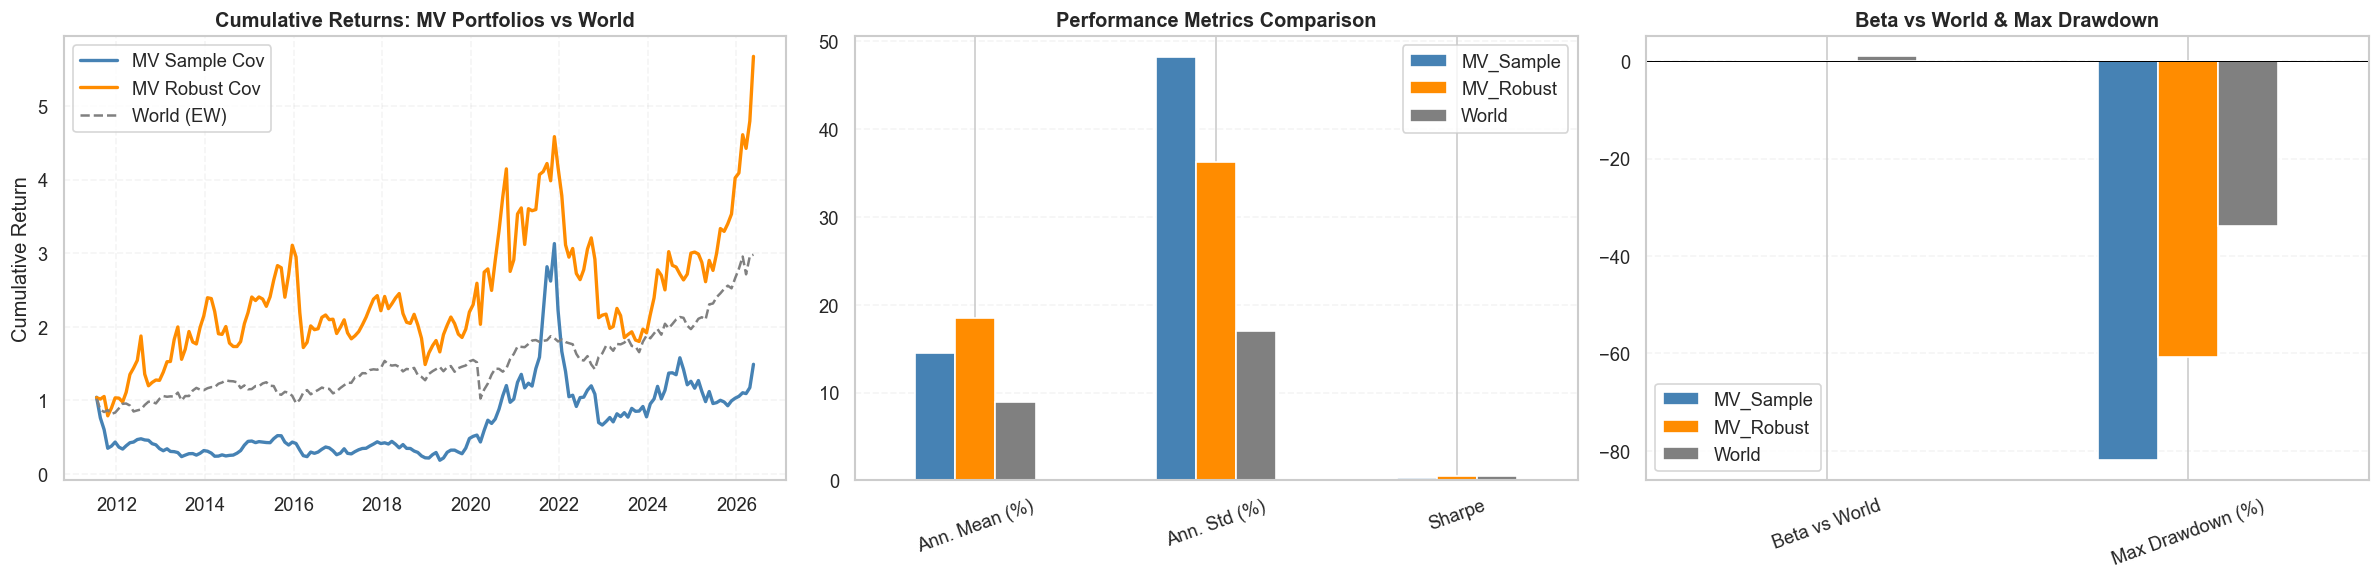


=== Full Comparison Table ===
                  MV_Sample  MV_Robust   World
Ann. Mean (%)        14.510     18.450   8.890
Ann. Std (%)         48.180     36.220  17.070
Sharpe                0.301      0.510   0.521
Max Drawdown (%)    -81.930    -60.680 -33.730
Beta vs World         0.263      0.149   1.006


In [19]:
# ── P8: MV Portfolio Comparison — Stats & Plots ─────────────────────────────
opt_both      = pd.concat([opt_sample, opt_robust], axis=1).dropna()
world_aligned = world_ret.reindex(opt_both.index)

# Full stats including beta and max drawdown for all three series
print("=== MV Portfolio Statistics ===")
labels = ['MV_Sample', 'MV_Robust', 'World']
series = [opt_both['MV_Sample'], opt_both['MV_Robust'], world_aligned]

mv_stats = {}
for label, s in zip(labels, series):
    st = portfolio_stats(s, benchmark=world_aligned)
    mv_stats[label] = st
    print(f"\n{label}:")
    for k, v in st.items():
        print(f"  {k}: {v}")

# ── Plots ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# Panel 1: Cumulative returns
cum_s = (1 + opt_both['MV_Sample']).cumprod()
cum_r = (1 + opt_both['MV_Robust']).cumprod()
cum_w = (1 + world_aligned).cumprod()

axes[0].plot(cum_s.index, cum_s, label='MV Sample Cov',  color='steelblue',  linewidth=2)
axes[0].plot(cum_r.index, cum_r, label='MV Robust Cov',  color='darkorange', linewidth=2)
axes[0].plot(cum_w.index, cum_w, label='World (EW)',      color='gray',       linewidth=1.5, linestyle='--')
axes[0].set_title('Cumulative Returns: MV Portfolios vs World', fontweight='bold')
axes[0].set_ylabel('Cumulative Return')
axes[0].legend()
axes[0].grid(True, alpha=0.2, linestyle='--')

# Panel 2: Key metrics bar chart (Mean, Std, Sharpe)
metrics = ['Ann. Mean (%)', 'Ann. Std (%)', 'Sharpe']
stats_comp = pd.DataFrame(
    {lbl: [mv_stats[lbl][m] for m in metrics] for lbl in labels},
    index=metrics
)
stats_comp.plot(kind='bar', ax=axes[1], edgecolor='white',
                color=['steelblue', 'darkorange', 'gray'])
axes[1].set_title('Performance Metrics Comparison', fontweight='bold')
axes[1].tick_params(axis='x', rotation=20)
axes[1].legend()
axes[1].grid(axis='y', alpha=0.2, linestyle='--')

# Panel 3: Beta and Max Drawdown
extra_metrics = ['Beta vs World', 'Max Drawdown (%)']
extra_comp = pd.DataFrame(
    {lbl: [mv_stats[lbl].get(m, np.nan) for m in extra_metrics] for lbl in labels},
    index=extra_metrics
)
extra_comp.plot(kind='bar', ax=axes[2], edgecolor='white',
                color=['steelblue', 'darkorange', 'gray'])
axes[2].axhline(0, color='black', linewidth=0.6)
axes[2].set_title('Beta vs World & Max Drawdown', fontweight='bold')
axes[2].tick_params(axis='x', rotation=20)
axes[2].legend()
axes[2].grid(axis='y', alpha=0.2, linestyle='--')

plt.tight_layout()
plt.savefig('mv_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n=== Full Comparison Table ===")
all_metrics = ['Ann. Mean (%)', 'Ann. Std (%)', 'Sharpe', 'Max Drawdown (%)', 'Beta vs World']
full_comp = pd.DataFrame(
    {lbl: [mv_stats[lbl].get(m, np.nan) for m in all_metrics] for lbl in labels},
    index=all_metrics
)
print(full_comp.to_string())